In [2]:
*| echo: false
*| output: false
use "material\lab-1\shs2023.dta", clear


Running C:\Users\ndl1\websites\st-andrews-ec3301\profile.do ...



(This dataset contains a subset of variables from the Scottish Household Survey
>  ()


In [3]:
*| eval: false
browse

In [4]:
*| echo: true
lookfor elec


Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
htcostsum_1     byte    %8.0g      htcostsum_1
                                              Cost of electricity - summary
                                                variable
htcostamt_1     int     %8.0g                 Cost of electricity - amount
                                                variable


In [5]:
*| eval: false
describe htcostsum_1

In [6]:
keep area RTParea MD20QUIN hhsize hb1 hb509 rent_amt rent_sum mortgage_amt mortgage_sum shared_ownership_sum shared_ownership_amt

In [7]:
*| eval: false
rename hb1 dwell_type

In [8]:
*| eval: false
label var dwell_type "Type of dwelling"

In [9]:
*| eval: false

* Title: Econometrics Lab 1: Working with data in Stata
* Author: [INSERT NAME]
* Date: [INSERT DATE]
  
* Open data
use "[INSERT FILE PATH]\shs2023.dta", clear

* Managing data

** 1. Remove all unnecessary variables using the command:

keep area RTParea MD20QUIN hhsize hb1 hb509 rent_amt rent_sum mortgage_amt mortgage_sum shared_ownership_sum shared_ownership_amt

In [10]:
*| echo: false
*| output: false

* Rename and re-label variables
rename hb1 dwell_type
label var dwell_type "Type of dwelling"

rename hb509 own_grp
label var own_grp "Ownership of the dwelling"

In [11]:
*| echo: true

codebook dwell_type


-------------------------------------------------------------------------------
dwell_type                                                     Type of dwelling
-------------------------------------------------------------------------------

                  Type: Numeric (byte)
                 Label: hb1

                 Range: [1,3]                         Units: 1
         Unique values: 3                         Missing .: 0/10,496

            Tabulation: Freq.   Numeric  Label
                        7,379         1  House or bungalow
                        3,086         2  A flat, maisonette or apartment
                                         (including )
                           31         3  Other, including room(s),
                                         caravan/mobile homes


In [12]:
*| echo: true

tab dwell_type


                       Type of dwelling |      Freq.     Percent        Cum.
----------------------------------------+-----------------------------------
                      House or bungalow |      7,379       70.30       70.30
A flat, maisonette or apartment (includ |      3,086       29.40       99.70
Other, including room(s), caravan/mobil |         31        0.30      100.00
----------------------------------------+-----------------------------------
                                  Total |     10,496      100.00


In [13]:
*| echo: true
numlabel, add
tab dwell_type


                       Type of dwelling |      Freq.     Percent        Cum.
----------------------------------------+-----------------------------------
                   1. House or bungalow |      7,379       70.30       70.30
2. A flat, maisonette or apartment (inc |      3,086       29.40       99.70
3. Other, including room(s), caravan/mo |         31        0.30      100.00
----------------------------------------+-----------------------------------
                                  Total |     10,496      100.00


In [14]:
*| echo: true
des MD20QUIN
label list MD20QUIN


Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
MD20QUIN        byte    %25.0g     MD20QUIN   SIMD 2020 - 1 = 20% most deprived
                                                to 5 = 20% least deprived
MD20QUIN:
           1 1. 1 - 20% most deprived
           2 2. 2
           3 3. 3
           4 4. 4
           5 5. 5 - 20% least deprived


In [15]:
*| echo: true
label def QUINTILE 1 "Bottom: 0-20%" 2 "Lower: 20-40%" 3 "Middle: 40-60%" 4 "Upper: 60-80%" 5 "Top: 80-100%"
label val MD20QUIN QUINTILE
tab MD20QUIN


 SIMD 2020 - 1 |
    = 20% most |
 deprived to 5 |
   = 20% least |
      deprived |      Freq.     Percent        Cum.
---------------+-----------------------------------
 Bottom: 0-20% |      1,928       18.37       18.37
 Lower: 20-40% |      2,061       19.64       38.00
Middle: 40-60% |      2,267       21.60       59.60
 Upper: 60-80% |      2,346       22.35       81.96
  Top: 80-100% |      1,894       18.04      100.00
---------------+-----------------------------------
         Total |     10,496      100.00


In [16]:
*| echo: true

sum rent_amt


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
    rent_amt |      3,414    477.6421     168.932        290        940


In [17]:
*| echo: true

sum rent_amt, detail
sum mortgage_amt, detail


       Amount of monthly rent for households that are
                          renting 
-------------------------------------------------------------
      Percentiles      Smallest
 1%          290            290
 5%          300            290
10%          320            290       Obs               3,414
25%          360            290       Sum of wgt.       3,414

50%          420                      Mean           477.6421
                        Largest       Std. dev.       168.932
75%          530            940
90%          750            940       Variance       28538.04
95%          900            940       Skewness       1.400969
99%          940            940       Kurtosis       4.203235

     Amount of monthly mortgage payments for households
                       with a mortgage
-------------------------------------------------------------
      Percentiles      Smallest
 1%          200            200
 5%          250            200
10%          300            200

In [18]:
*| echo: true

sum rent_amt if rent_sum==1


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
    rent_amt |      2,229    490.4217    165.7097        290        940


In [19]:
*| echo: true

tab MD20QUIN, sum(rent_amt)


SIMD 2020 - |
    1 = 20% |
       most |
deprived to |
    5 = 20% |  Summary of Amount of monthly rent
      least |  for households that are renting 
   deprived |        Mean   Std. dev.       Freq.
------------+------------------------------------
  Bottom: 0 |   427.22591    112.6494       1,204
  Lower: 20 |   451.14679   147.98941         872
  Middle: 4 |   490.12012   166.84147         666
  Upper: 60 |   537.70925   192.60511         454
  Top: 80-1 |   698.85321   231.81326         218
------------+------------------------------------
      Total |   477.64206   168.93205       3,414


In [20]:
*| echo: true

table MD20QUIN, stat(mean rent_amt) stat(sd rent_amt) stat(count rent_amt)

--------------------------------------------------------------------------------------------------------------------------
                                                            |      Mean   Standard deviation   Number of nonmissing values
------------------------------------------------------------+-------------------------------------------------------------
SIMD 2020 - 1 = 20% most deprived to 5 = 20% least deprived |                                                             
  Bottom: 0-20%                                             |  427.2259             112.6494                         1,204
  Lower: 20-40%                                             |  451.1468             147.9894                           872
  Middle: 40-60%                                            |  490.1201             166.8415                           666
  Upper: 60-80%                                             |  537.7093             192.6051                           454
  Top: 80-100%  

In [21]:
*| echo: true

tabstat rent_amt, by(MD20QUIN) stat(mean sd count) 


Summary for variables: rent_amt
Group variable: MD20QUIN (SIMD 2020 - 1 = 20% most deprived to 5 = 20% least de
> prived)

      MD20QUIN |      Mean        SD         N
---------------+------------------------------
 Bottom: 0-20% |  427.2259  112.6494      1204
 Lower: 20-40% |  451.1468  147.9894       872
Middle: 40-60% |  490.1201  166.8415       666
 Upper: 60-80% |  537.7093  192.6051       454
  Top: 80-100% |  698.8532  231.8133       218
---------------+------------------------------
         Total |  477.6421   168.932      3414
----------------------------------------------


In [22]:
*| echo: true
gen amt_sum = .

(10,496 missing values generated)


In [23]:
*| echo: true
sum amt_sum


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     amt_sum |          0


In [24]:
*| echo: true
replace amt_sum = 1 if rent_amt > 0 & rent_amt != .
replace amt_sum = 2 if mortgage_amt > 0 & mortgage_amt != .
replace amt_sum = 3 if shared_ownership_amt > 0 & shared_ownership_amt != .

(3,414 real changes made)
(2,552 real changes made)
(83 real changes made)


In [25]:
tab amt_sum, missing


    amt_sum |      Freq.     Percent        Cum.
------------+-----------------------------------
          1 |      3,414       32.53       32.53
          2 |      2,552       24.31       56.84
          3 |         83        0.79       57.63
          . |      4,447       42.37      100.00
------------+-----------------------------------
      Total |     10,496      100.00


(bin=35, start=290, width=18.571429)


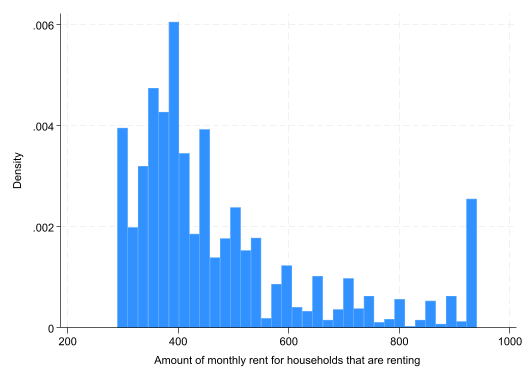

In [26]:
*| echo: false
hist rent_amt 

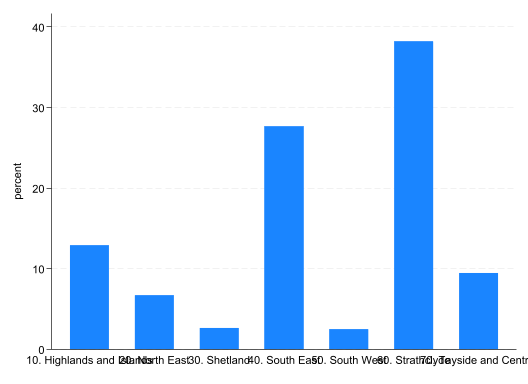

In [27]:
*| echo: false
graph bar, over(RTParea) 

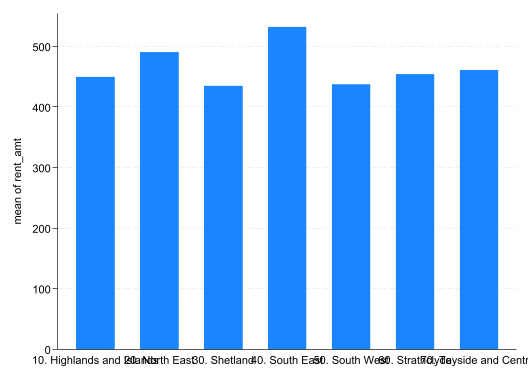

In [28]:
*| echo: false
graph bar (mean) rent_amt, over(RTParea)

In [29]:
*| eval: false
*| echo: true
graph save "[INSERT FILE PATH]\EC3301\Lab 1\graph.gph", replace

In [30]:
*| eval: false
*| echo: true
graph export "[INSERT FILE PATH]\EC3301\Lab 1\file_name.png", replace

In [31]:
*| eval: false
*| echo: true
log using "[INSERT FILE PATH]\EC3301\Lab 1\lab-1.smcl", replace

In [32]:
*| eval: false
*| echo: true
log close

In [33]:
*| eval: false
*| echo: true
cap log close
log using "[INSERT FILE PATH]\EC3301\Lab 1\lab_1.txt", replace text

In [34]:
*| eval: false
*| echo: true
log close

In [35]:
*| eval: false
*| echo: true
cd "[INSERT FILE PATH]\EC3301\Lab 1"

In [36]:
*| eval: false
*| echo: true
graph export "file_name.png", replace

In [37]:
*| eval: false

* Title: Econometrics Lab 1: Working with data in Stata
* Author: [INSERT NAME]
* Date: [INSERT DATE]

* Clear all objects in memory
clear all

* Set directory
cd "[INSERT FILE PATH]\EC3301\Lab 1"

* Start log
cap log close
log using lab_1.txt, replace text

* Open data
use "shs2023.dta"


[ALL THE EXERCISES GO HERE!]


* Close log
log close